# **Titanic Survival Prediction - Hyper-Detailed Version**

In this notebook, we follow a step-by-step process to predict if a passenger on the Titanic survived. We explain every single step in simple language so you can follow along easily.

Step 1: Importing Our Tools

We need special libraries to work with data:

Pandas (pd): Used for handling tables (like Excel sheets).

Numpy (np): Used for doing math and handling numbers efficiently.

Seaborn (sb) & Matplotlib (plt): Used for drawing pretty charts and graphs so we can see the data visually.

In [39]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


# **Step 2: Loading the Dataset**

We have a file named train.csv that contains info about the passengers (age, gender, class, etc.). This line of code reads that file and stores all that information into a variable called df (DataFrame).

In [40]:
from google.colab import files
uploaded=files.upload()


Saving train.csv to train (1).csv


In [41]:
train = pd.read_csv('train.csv')

# Step 3: Looking at the Top Rows

Now that we loaded the data, we use df.head() to see the first 5 rows. This helps us confirm that the data loaded correctly and see what columns (like Survived, Pclass, Name) we have

In [42]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [43]:
train.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


# **Step 4: Checking Data Types and Empty Spots**

We use df.info() to see a summary of our columns. It tells us how many entries are 'non-null' (not empty). For example, if we see 'Age' has only 714 entries out of 891, we know some ages are missing.

In [44]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


# **Step 5: Statistical Summary**

This gives us a math summary of the numbers in our data. It shows the mean (average age), min (youngest person), and max (oldest person). It's a quick way to see the range of our data.

In [45]:
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


**Step 6: Visualizing Missing Data (The 'Holes')**

This code draws a heatmap. If there is a light-colored spot, it means data is missing in that column. Looking at this chart, we can quickly see that 'Age' has some missing spots and 'Cabin' has a lot of missing spots.

<Axes: >

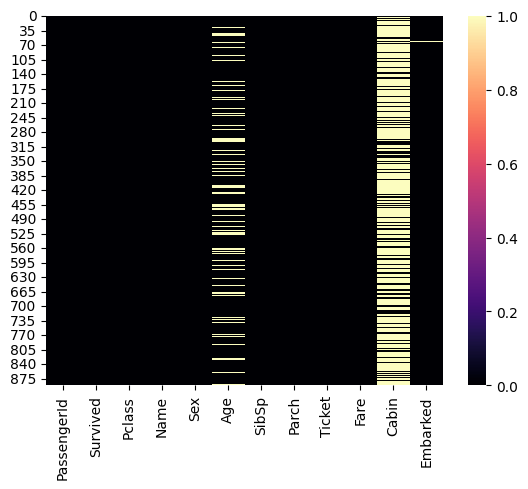

In [46]:
sns.heatmap(train.isnull(),cmap='magma')

<Axes: >

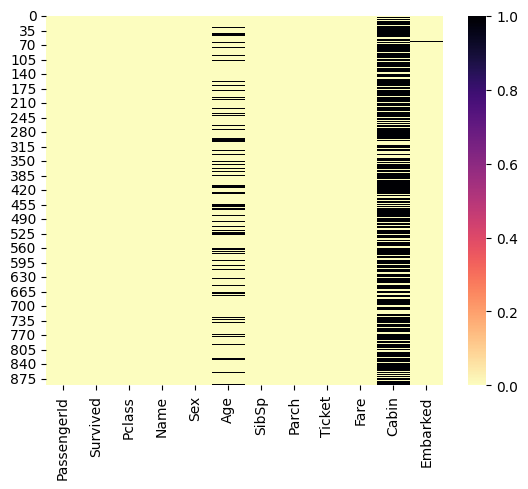

In [47]:
sns.heatmap(train.isnull(),cmap='magma_r')

<Axes: >

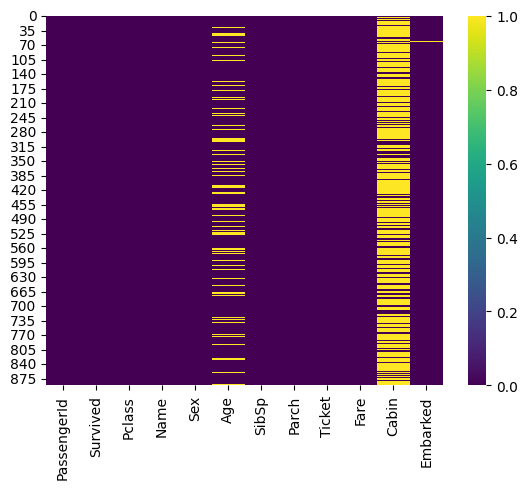

In [48]:
sns.heatmap(train.isnull(),cmap='viridis')

<Axes: >

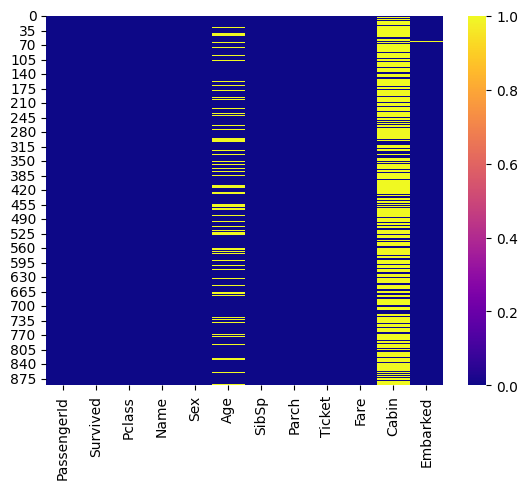

In [49]:
sns.heatmap(train.isnull(),cmap='plasma')
#inferno
#blues
#greens
#YlOrRd


# **Step 7: Defining Deck Letters**

Passengers on the Titanic stayed on different levels called 'Decks' (A, B, C, etc.). Here, we create a list of all possible deck letters we might find in the 'Cabin' column, plus a category for 'Unknown' if the info is missing.

In [50]:
cabin_list = ['A','B','C','D','E','F','G','Unknown']

# **Step 8: Function to Find the Deck**

This is a helper function. It takes a Cabin string (like 'C123') and looks if it contains one of our Deck letters. If it finds 'C', it tells us the person was on Deck C. If it doesn't find anything, it returns 'Unknown'.

In [51]:
def search_substring(big_string,substring_list):
  for substring in substring_list:
    if substring in big_string:
      return substring
  return substring_list[-1]



In [52]:
import re

In [53]:
a = "my name is shravani"
v = re.search("shravani",a)
print(v.group())


shravani


# **Step 9: Function to Extract Titles (Mr, Mrs, Miss)**

Every passenger's name contains a title (like 'Braund, Mr. Owen Harris'). This function uses 'Regular Expressions' (Regex) to search for specific words like 'Mr', 'Mrs', or 'Master' inside the name string and returns just that title.

In [54]:
def get_title(string): # WE HAVE DECLARED A FUNCTION IT HAS PARAMETER STRING THAT PARAMETER CONTAINS PASSANGER NAMES
  import re # REGULAR EXPRESSION MODEL IN PYTHON IS USED FOR PATTERN MATCHING
  regex=re.compile(r'Mr|Don|Major|Capt|Jonkheer|Rev|Col|Dr|Mrs|Countess|Dona|Mme|Ms|Miss|Mlle|Master',re.IGNORECASE) #
  results = regex.search(string) # SCAN THE STRING
  if results != None:
    return(results.group().lower()) # return it in smaller case
  else:
    return(str(np.nan)) #

In [55]:
get_title("Braund, Mr. Owen Harris")

'mr'

# **Step 10: Mapping and Grouping Titles**

There are many rare titles (like 'Capt' or 'Don'). To make it easier for our model, we group them into main categories. For example, 'Mme' (Madame) becomes 'Mrs', and 'Capt' (Captain) becomes 'Officer'. This keeps our data focused.

In [56]:
# dictionary to map to generate the new feature vector
title_dictionary = {
"capt":"Officer",
"col":"Officer",
"major":"Officer",
"dr":"Officer",
"jonkheer":"Royalty",
"rev":"Officer",
"countess":"Royalty",
"dona":"Royalty",
"lady":"Royalty",
"don":"Royalty",
"mr":"Mr",
"mme":"Mrs",
"ms":"Mrs",
"mrs":"Mrs",
"miss":"Miss",
"mlle":"Miss",
"master":"Master",
"nan":"Mr"
}

# **Step 11: Creating the 'Deck' Column**

We now use our search_substring function on every row in the 'Cabin' column. The result is a new, clean column called 'Deck' that only contains letters like A, B, C, or 'Unknown'.

In [57]:
train['Deck'] = train['Cabin'].map(lambda x: search_substring(str(x),cabin_list))
#test_set['deck']= test_set['cabin'].map(lambda x : search_substring(str(x)),cabin_list)
train.drop('Cabin', axis=1, inplace=True)
#
train['Title']= train['Name'].apply(get_title)
#
train['Title']=train['Title'].map(title_dictionary)

# **Step 12: Removing the Old 'Cabin' Column**

Now that we have the important 'Deck' info, we don't need the messy 'Cabin' column anymore. This line deletes it from our table.

In [58]:
#delete the name feature
train.drop('Name', axis=1, inplace = True)
train.tail()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Deck,Title
886,887,0,2,male,27.0,0,0,211536,13.00,S,Unknown,Officer
887,888,1,1,female,19.0,0,0,112053,30.00,S,B,Miss
888,889,0,3,female,NaN,1,2,W./C. 6607,23.45,S,Unknown,Miss
889,890,1,1,male,26.0,0,0,111369,30.00,C,C,Mr
890,891,0,3,male,32.0,0,0,370376,7.75,Q,Unknown,Mr


In [59]:
train.drop('Ticket', axis=1, inplace = True)
train.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Deck,Title
0,1,0,3,male,22.0,1,0,7.2500,S,Unknown,Mr
1,2,1,1,female,38.0,1,0,71.2833,C,C,Mr
2,3,1,3,female,26.0,0,0,7.9250,S,Unknown,Miss
3,4,1,1,female,35.0,1,0,53.1000,S,C,Mr
4,5,0,3,male,35.0,0,0,8.0500,S,Unknown,Mr


# Step 13: Calculating Average Age by Title

Some people are missing their 'Age'. Instead of giving them a random age, we calculate the average age for each Title. For example, 'Master' usually refers to young boys, so his average age will be low, while 'Mr' will be higher.

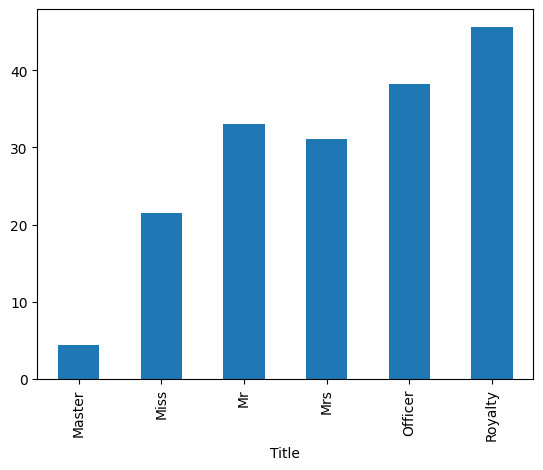

In [60]:
means_title = train.groupby('Title')['Age'].mean()
mk = train.groupby('Title')['Age'].mean().plot(kind='bar')

# Step 14: Function to Fill Missing Ages

This function is smart. If someone is missing an age, it checks their 'Title' and gives them the average age we calculated for that group in Step 13.

In [61]:
title_list = ['Mr','Mrs','Miss','Master','Royalty','Officer']
def age_nan_replace(means, dframe, title_list):
  for title in title_list:
    temp = dframe['Title']== titledframe
    dframe.loc[remp, 'Age']= dframe.loc[temp,'Age'].fillna(means[title])
    age_nan_replace(means_title, train, title_list)


In [62]:
train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Sex          891 non-null    object 
 4   Age          714 non-null    float64
 5   SibSp        891 non-null    int64  
 6   Parch        891 non-null    int64  
 7   Fare         891 non-null    float64
 8   Embarked     889 non-null    object 
 9   Deck         891 non-null    object 
 10  Title        891 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


<Axes: >

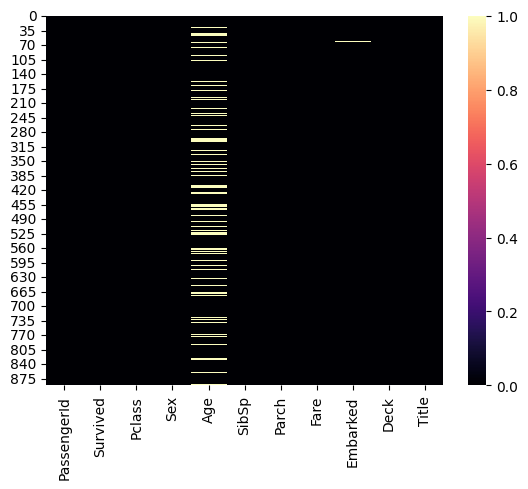

In [63]:
sns.heatmap(train.isnull(),cmap='magma')

<Axes: xlabel='Embarked'>

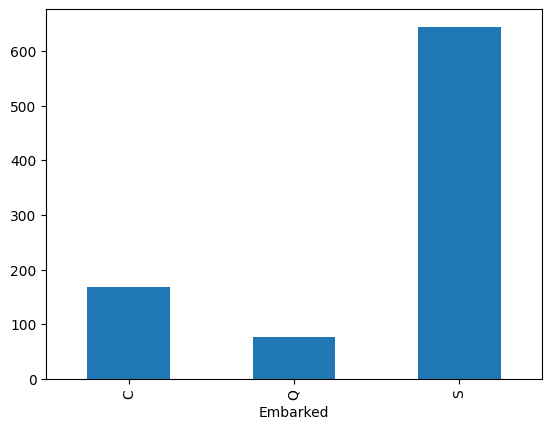

In [64]:
train.groupby('Embarked').size().plot(kind='bar')

In [65]:
train['Embarked'].fillna('S', inplace= True)
train.head()

/tmp/ipykernel_3516/3343457148.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train['Embarked'].fillna('S', inplace= True)


,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Deck,Title
0,1,0,3,male,22.0,1,0,7.2500,S,Unknown,Mr
1,2,1,1,female,38.0,1,0,71.2833,C,C,Mr
2,3,1,3,female,26.0,0,0,7.9250,S,Unknown,Miss
3,4,1,1,female,35.0,1,0,53.1000,S,C,Mr
4,5,0,3,male,35.0,0,0,8.0500,S,Unknown,Mr


<Axes: >

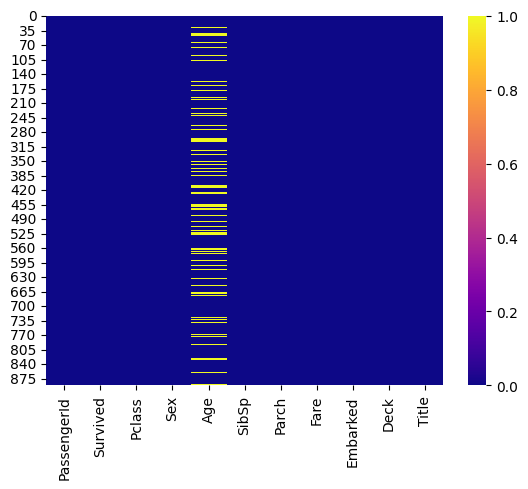

In [66]:
sns.heatmap(train.isnull(),cmap='plasma')

/tmp/ipykernel_3516/1994222299.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  train.pivot_table('Survived', parch_intervals,'Sex').plot(kind='bar')


<Axes: xlabel='Parch'>

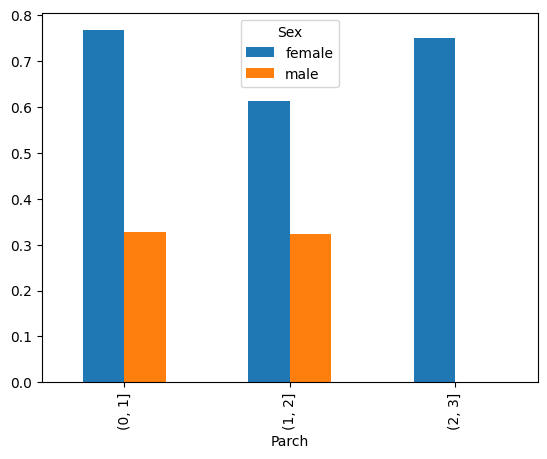

In [67]:
parch_intervals = pd.cut(train['Parch'],[0,1,2,3])
train.pivot_table('Survived', parch_intervals,'Sex').plot(kind='bar')

/tmp/ipykernel_3516/11558511.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  train.pivot_table('Survived', sibsp_intervals,'Sex').plot(kind='bar')


<Axes: xlabel='SibSp'>

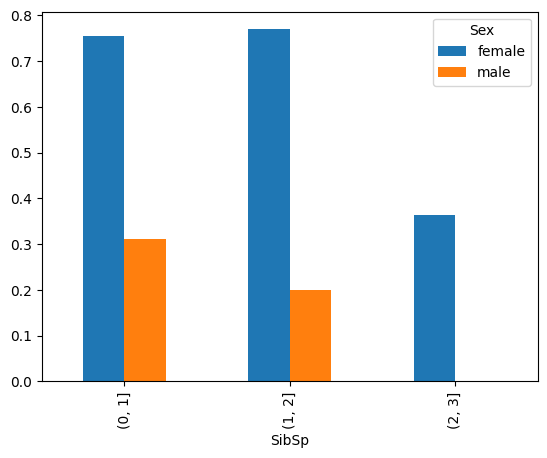

In [68]:
sibsp_intervals = pd.cut(train['SibSp'],[0,1,2,3])
train.pivot_table('Survived', sibsp_intervals,'Sex').plot(kind='bar')

In [74]:
train['Family_Size']= train['Parch']+train['SibSp']
train.drop('Parch',axis=1, inplace=True)
train.drop('SibSp',axis=1, inplace=True)
train.head()

,PassengerId,Survived,Pclass,Sex,Age,Fare,Embarked,Deck,Title,Family_Size
0,1,0,3,1,22.0,7.2500,2,7,2,1
1,2,1,1,0,38.0,71.2833,0,2,2,1
2,3,1,3,0,26.0,7.9250,2,7,1,0
3,4,1,1,0,35.0,53.1000,2,2,2,1
4,5,0,3,1,35.0,8.0500,2,7,2,0


In [71]:
from sklearn.preprocessing import LabelEncoder

cols = ['Sex', 'Embarked', 'Deck', 'Title']
for col in cols:
    le = LabelEncoder()
    train[col] = le.fit_transform(train[col].astype(str))

print("Encoding complete. Categorical columns converted to numeric.")
train.head()

Encoding complete. Categorical columns converted to numeric.


,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Deck,Title
0,1,0,3,1,22.0,1,0,7.2500,2,7,2
1,2,1,1,0,38.0,1,0,71.2833,0,2,2
2,3,1,3,0,26.0,0,0,7.9250,2,7,1
3,4,1,1,0,35.0,1,0,53.1000,2,2,2
4,5,0,3,1,35.0,0,0,8.0500,2,7,2


# ** Separating Features and Target**
We split the data into X (Factors like gender, age, class) and y (The Goal: did they survive?). We also remove PassengerId because it's just a sequence number and doesn't reveal anything about survival.

In [72]:
X = train.drop(['Survived', 'PassengerId'], axis=1)
y = train['Survived']

print(f"Features: {X.columns.tolist()}")
print(f"Target: Survived")

Features: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Deck', 'Title']
Target: Survived


# ** Splitting into Training and Testing Sets**
We want to test if our model is actually good. We hide 20% of the data from the model. It will 'study' the 80% (Training set) and we will 'test' it on the remaining 20% (Testing set) to see how many people it guesses correctly.

In [73]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data size: {X_train.shape[0]} rows")
print(f"Testing data size: {X_test.shape[0]} rows")

Training data size: 712 rows
Testing data size: 179 rows


# **Training the Random Forest Model**

A 'Random Forest' is like a group of experts voting on whether someone survives. We give it the training data so it can 'learn' the patterns of survival (e.g., 'Women and children first').

In [75]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train the model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Model training finished!")

Model training finished!


## **Calculating the Accuracy**
Finally, we see how the model performed. This 'Accuracy Score' tells us what percentage of people in our hidden test set the model correctly predicted as survivors or non-survivors.

In [76]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Make predictions
y_pred = model.predict(X_test)

# Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Overall Accuracy: {accuracy*100:.2f}%\n")

# Detailed Report
print("Detailed Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Overall Accuracy: 84.92%

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.90      0.87       105
           1       0.84      0.78      0.81        74

    accuracy                           0.85       179
   macro avg       0.85      0.84      0.84       179
weighted avg       0.85      0.85      0.85       179

Confusion Matrix:
[[94 11]
 [16 58]]
